<a href="https://colab.research.google.com/github/Arooba93/MyProjects/blob/main/hugging_face_vit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### https://huggingface.co/datasets/Chanura04/CT-Scan-Brain-Tumor - dataset
###https://huggingface.co/google/vit-base-patch16-224-in21k - image classification model

###installing Hugging Face libraries and visualization tools.

In [ ]:
!pip install -q transformers datasets scikit-learn matplotlib seaborn accelerate torch torchvision

In [ ]:
import os
import numpy as np
import torch
from datasets import load_dataset, Dataset
from tqdm.auto import tqdm

print("⚡ Streaming and shuffling dataset to ensure random class distribution...")

# 1. Stream the data and apply a shuffle buffer to mix the classes before downloading
streamed_dataset = load_dataset("Chanura04/CT-Scan-Brain-Tumor", split="train", streaming=True)
shuffled_stream = streamed_dataset.shuffle(seed=42, buffer_size=3000)

# 2. Extract exactly 600 randomized images
num_samples = 600
samples = list(tqdm(shuffled_stream.take(num_samples), total=num_samples, desc="Fetching random images"))

# 3. Convert to an optimized PyTorch dataset
master_dataset = Dataset.from_list(samples)

# 4. Extract labels and dynamically map classes
labels_array = master_dataset['label']
label_list = master_dataset.features['label'].names if hasattr(master_dataset.features['label'], 'names') else sorted(list(set(labels_array)))
num_classes = len(label_list)

id2label = {i: str(label) for i, label in enumerate(label_list)}
label2id = {str(label): i for i, label in enumerate(label_list)}

print(f"\n✅ Loaded {len(master_dataset)} random CT scans.")
print("Class Distribution Check:")
for i in range(num_classes):
    print(f" - {label_list[i]}: {labels_array.count(i)} images")

⚡ Streaming and shuffling dataset to ensure random class distribution...


Resolving data files:   0%|          | 0/4618 [00:00<?, ?it/s]

Fetching random images:   0%|          | 0/600 [00:00<?, ?it/s]


✅ Loaded 600 random CT scans.
Class Distribution Check:
 - 0: 418 images
 - 1: 182 images


In [ ]:
from transformers import AutoImageProcessor

model_checkpoint = "google/vit-base-patch16-224-in21k"
image_processor = AutoImageProcessor.from_pretrained(model_checkpoint)

def transform_images(batch):
    # Convert images to standard RGB arrays expected by ViT
    inputs = image_processor([img.convert("RGB") for img in batch['image']], return_tensors='pt')
    inputs['labels'] = batch['label']
    return inputs

prepared_dataset = master_dataset.with_transform(transform_images)
print("✅ ViT Image Processor configured.")

✅ ViT Image Processor configured.


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve, confusion_matrix
from transformers import AutoModelForImageClassification

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple): logits = logits[0]

    preds = np.argmax(logits, axis=-1)
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()

    acc = accuracy_score(labels, preds)

    # Calculate Precision, Recall, F1, and AUC dynamically
    if num_classes == 2:
        precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
        auc = roc_auc_score(labels, probs[:, 1])
    else:
        precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
        auc = roc_auc_score(labels, probs, multi_class='ovr', average='macro')

    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1, "auc": auc}

def model_init():
    # Initializes a fresh pre-trained model for each fold to avoid data leakage
    return AutoModelForImageClassification.from_pretrained(
        model_checkpoint,
        num_labels=num_classes,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )
print("✅ Metrics and Model Initialization functions ready.")

✅ Metrics and Model Initialization functions ready.


In [ ]:
from sklearn.model_selection import StratifiedKFold
from transformers import TrainingArguments, Trainer, DefaultDataCollator

epochs = 10
num_folds = 3
skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

all_metrics_results, all_cms, roc_data, loss_data = [], [], [], []

print(f"========== STARTING ViT CV PIPELINE ({num_folds} Folds, {epochs} Epochs per Fold) ==========\n")

for fold, (train_idx, val_idx) in enumerate(tqdm(skf.split(np.zeros(len(labels_array)), labels_array), total=num_folds, desc="Overall CV Progress")):

    train_fold = prepared_dataset.select(train_idx)
    val_fold = prepared_dataset.select(val_idx)

    save_path = f"./vit_ctscan_saves/fold_{fold+1}"

    training_args = TrainingArguments(
        output_dir=save_path,
        num_train_epochs=epochs,
        per_device_train_batch_size=16,
        gradient_accumulation_steps=2,
        fp16=True,
        learning_rate=3e-5,
        lr_scheduler_type="cosine",
        remove_unused_columns=False,
        dataloader_num_workers=0,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=5,
        load_best_model_at_end=True,
        disable_tqdm=False,
    )

    trainer = Trainer(
        model_init=model_init,
        args=training_args,
        train_dataset=train_fold,
        eval_dataset=val_fold,
        data_collator=DefaultDataCollator(),
        compute_metrics=compute_metrics,
    )

    trainer.train()
    eval_metrics = trainer.evaluate()
    trainer.save_model(save_path)

    clean_metrics = {k.replace('eval_', ''): v for k, v in eval_metrics.items() if isinstance(v, float)}
    all_metrics_results.append(clean_metrics)

    train_loss = [log['loss'] for log in trainer.state.log_history if 'loss' in log]
    loss_data.append(train_loss)

    # Generate predictions
    predictions = trainer.predict(val_fold)
    preds_logits = predictions.predictions
    if isinstance(preds_logits, tuple): preds_logits = preds_logits[0]

    preds_labels = np.argmax(preds_logits, axis=-1)
    preds_probs = torch.nn.functional.softmax(torch.tensor(preds_logits), dim=-1).numpy()

    # THE FIX: Grab the perfectly formatted integer labels directly from the Trainer
    val_labels_array = predictions.label_ids

    if num_classes == 2:
        fpr, tpr, _ = roc_curve(val_labels_array, preds_probs[:, 1])
    else:
        fpr, tpr, _ = roc_curve(val_labels_array == 0, preds_probs[:, 0])

    roc_data.append((fpr, tpr, clean_metrics.get('auc', 0.0)))
    all_cms.append(confusion_matrix(val_labels_array, preds_labels, labels=range(num_classes)))

========== STARTING ViT CV PIPELINE (3 Folds, 10 Epochs per Fold) ==========



Overall CV Progress:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Auc
0.028654,0.106322,10,0.970000,1.000000,0.901639,0.948276,0.998113


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  CROSS-VALIDATION EVALUATION RESULTS (AVERAGE ± STD)
  Accuracy: 0.9733 ± 0.0047
 Precision: 0.9830 ± 0.0136
    Recall: 0.9288 ± 0.0276
        F1: 0.9547 ± 0.0085
       Auc: 0.9923 ± 0.0070


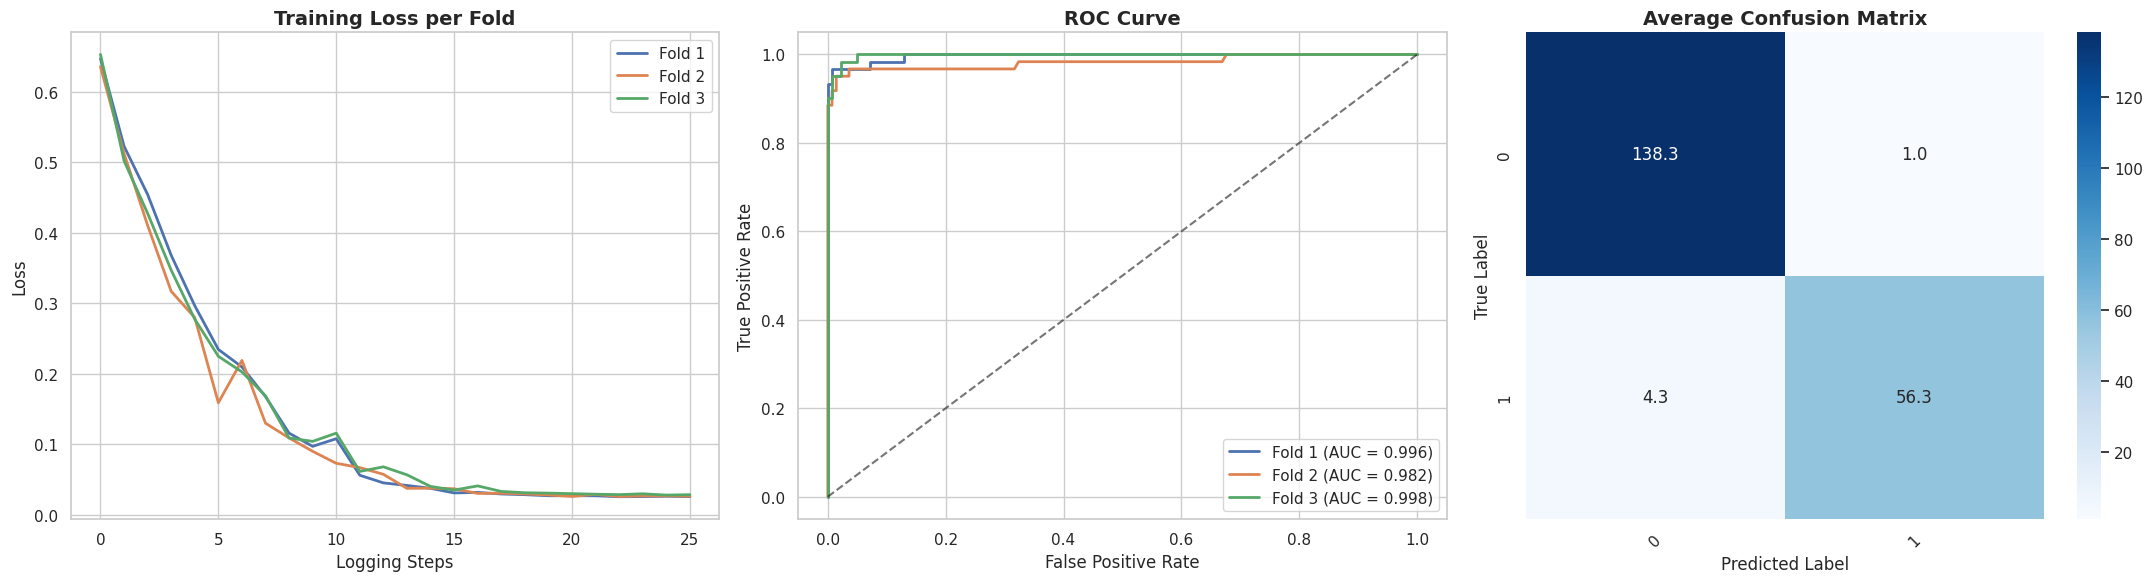

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*60)
print("  CROSS-VALIDATION EVALUATION RESULTS (AVERAGE ± STD)")
print("="*60)
metrics_keys = ['accuracy', 'precision', 'recall', 'f1', 'auc']
for key in metrics_keys:
    values = [m[key] for m in all_metrics_results]
    print(f"{key.capitalize():>10}: {np.mean(values):.4f} ± {np.std(values):.4f}")
print("="*60)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for i, losses in enumerate(loss_data):
    axes[0].plot(losses, label=f'Fold {i+1}', linewidth=2)
axes[0].set_title('Training Loss per Fold', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Logging Steps', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend()

roc_title = 'ROC Curve' if num_classes == 2 else f'ROC Curve ({label_list[0]} vs Rest)'
for i, (fpr, tpr, auc_val) in enumerate(roc_data):
    axes[1].plot(fpr, tpr, label=f'Fold {i+1} (AUC = {auc_val:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.6)
axes[1].set_title(roc_title, fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].legend(loc="lower right")

avg_cm = np.mean(all_cms, axis=0)
sns.heatmap(avg_cm, annot=True, fmt='.1f', cmap='Blues', ax=axes[2],
            xticklabels=label_list, yticklabels=label_list)
axes[2].set_title('Average Confusion Matrix', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Predicted Label', fontsize=12)
axes[2].set_ylabel('True Label', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()